**Aim:** make figures for Fig.6 in the manuscript

**Author:** Yike Xie

**Date Updated:** 30 Mar 2026

In [1]:
# Load libraries
import os
import re
import sys
sys.path.append("..")
import utils
get_ipython().run_line_magic('matplotlib', 'inline')

import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42

from scipy.stats import spearmanr
from adjustText import adjust_text

import warnings
warnings.filterwarnings("ignore")

In [ ]:
fig_folder = '../../figures/manuscript_figures/figure6/'
data_folder = '../../data/'

os.makedirs(fig_folder, exist_ok=True)
os.makedirs(data_folder, exist_ok=True)

# Data Loading

## basic information

In [3]:
metadata = pd.read_excel('../../figures/manuscript_figures/tables/Table1_human_donor_information.xlsx', 
                       index_col=0, sheet_name='Pancreas')

tech_cols = ["snRNA-Seq", "Immunostaining", "Spatial transcriptomics", "Calcium imaging", "Slice-Seq"]
tech_mask = metadata[tech_cols].astype(str).apply(lambda s: s.str.lower().str.strip().eq("yes"))

metadata["Method"] = tech_mask.apply(
    lambda row: ", ".join([col for col, ok in row.items() if ok]),
    axis=1
)

## spatial data

In [ ]:
# this is the data after neighborhood and subtype annotation
adata = sc.read_h5ad('../../data/YK_raw_spatial_ct_cst_c2l_annot_hq_neighbor_clustering_20260107.h5ad')

In [8]:
adata_raw = adata.copy()

# all_mac as the log2 normalized version
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)  # CP10K scale
sc.pp.log1p(adata, base=2) # log2 transform

- 'sample' column is the sample column
- 'barcode' (also index/obs_names) are the spatial barcodes for each spot on the curio slide
- 'x'/'y' are the spatial coords

## load preliminary data

In [ ]:
# load islet features
islet_features = pd.read_csv(
    '../../tables/spatial/islet_analysis/spatial_islet_features.tsv', 
    sep='\t', index_col=1)

## functions

In [10]:
from scipy.stats import rankdata, t
from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.multitest import multipletests

def spearman_corr(X, y, gene_exps):
    # Optional: handle NaNs (drop any sample with NaN in BMI or any gene)
    # If NaNs are sparse, you might prefer per-gene masking instead of global drop.
    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y = y[mask]
    X = X[mask, :]
    n, p = X.shape

    # 1) Rank-transform (column-wise for X, vector for y)
    y_rank = rankdata(y, method='average')              # (n,)
    X_rank = np.apply_along_axis(rankdata, 0, X)        # (n, p)

    # 2) Z-score ranks (so Pearson on ranks = Spearman)
    y_z = (y_rank - y_rank.mean()) / y_rank.std(ddof=1)            # (n,)
    X_z = (X_rank - X_rank.mean(axis=0)) / X_rank.std(axis=0, ddof=1)  # (n, p)

    # 3) Correlations in one shot: r = (y_z^T X_z) / (n-1)
    rho = (y_z @ X_z) / (n - 1)                         # (p,)

    # 4) p-values via t distribution with df = n-2
    #    t = r * sqrt((n-2)/(1-r^2))
    den = np.clip(1 - rho**2, 1e-15, None) # ensures the denominator never goes below 1e-15
    tvals = rho * np.sqrt((n - 2) / den) # test statistic
    pvals = 2 * t.sf(np.abs(tvals), df=n - 2) # two-sided p-values, 
    # t.sf(x, df) survival function = P(T>x) for a Student’s t-distribution with df degrees of freedom

    # 5) Assemble results + FDR
    sp_corr = pd.DataFrame({'rho': rho, 'pval': pvals}, index=gene_exps.index)
    sp_corr = sp_corr.sort_values('rho', ascending=False)
    
    return sp_corr

def pearson_corr(X, y, gene_exps):
    # 0) Handle NaNs: drop any sample with NaN in y or any gene (global mask)
    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y = y[mask]
    X = X[mask, :]
    n, p = X.shape

    # 1) Z-score raw data (Pearson uses centered, scaled values)
    y_z = (y - y.mean()) / y.std(ddof=1)                 # (n,)
    X_mean = X.mean(axis=0)                               # (p,)
    X_std  = X.std(axis=0, ddof=1)                        # (p,)
    # avoid divide-by-zero for constant genes
    X_std[X_std == 0] = np.nan
    X_z = (X - X_mean) / X_std                            # (n, p)

    # 2) Correlations in one shot: r = (y_z^T X_z) / (n-1)
    rho = (y_z @ X_z) / (n - 1)                           # (p,)
    # genes with zero variance -> nan; you can set to 0 if you prefer:
    # rho = np.nan_to_num(rho, nan=0.0)

    # 3) Two-sided p-values via t distribution with df = n-2
    #    t = r * sqrt((n-2)/(1-r^2))
    den = np.clip(1 - rho**2, 1e-15, None)
    tvals = rho * np.sqrt((n - 2) / den)
    pvals = 2 * t.sf(np.abs(tvals), df=n - 2)

    # 4) Assemble results (+ optional FDR)
    pearson_corr = pd.DataFrame({'r': rho, 'pval': pvals}, index=gene_exps.index)
    pearson_corr = pearson_corr.sort_values('r', ascending=False)
    
    return pearson_corr

In [11]:
import gseapy as gp

def get_pth_res(genes, gene_sets, fig_FDR, n_entities):
    
    all_results = []
    for gs in gene_sets:
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets=gs,
            organism='Human',
            cutoff=False)
        res = enr.res2d.copy()
        all_results.append(res)

    df = pd.concat(all_results, ignore_index=True)

    df['Pathway identifier'] = df['Term'].str.split('(').str[-1].str[:-1]
    df['#Entities found'] = df['Overlap'].str.split('/').str[0].astype('int')
    df['#Entities total'] = df['Overlap'].str.split('/').str[1].astype('int')

    df_strict = df[
            (df['Adjusted P-value'] < fig_FDR) # < 0.1
            & (df['#Entities found'].astype('int') > n_entities)
        ]

    return df_strict

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from scipy.spatial import ConvexHull
from matplotlib.path import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colors import to_rgb, to_hex

def midpoint_hex(h1, h2):
    rgb1, rgb2 = np.array(to_rgb(h1)), np.array(to_rgb(h2))
    return to_hex((rgb1+rgb2)/2)

def _hex_to_rgb01(h): 
    h = h.lstrip("#"); return np.array([int(h[i:i+2],16) for i in (0,2,4)])/255

def _srgb_to_linear(c): 
    a=0.055; return np.where(c<=0.04045, c/12.92, ((c+a)/(1+a))**2.4)
def _linear_to_srgb(c): 
    a=0.055; return np.where(c<=0.0031308, 12.92*c, (1+a)*(np.clip(c,0,1)**(1/2.4))-a)

M1 = np.array([[0.41222147,0.53633254,0.05144599],
               [0.21190350,0.68069955,0.10739696],
               [0.08830246,0.28171884,0.62997870]])
M2 = np.array([[0.21045426,0.79361779,-0.00407205],
               [1.97799850,-2.42859221,0.45059371],
               [0.02590404,0.78277177,-0.80867576]])
M1i, M2i = np.linalg.inv(M1), np.linalg.inv(M2)

def _hex_to_oklab(h):
    lin = _srgb_to_linear(_hex_to_rgb01(h)); lms = M1 @ lin; lms_c = np.cbrt(lms); return M2 @ lms_c
def _oklab_to_hex(Lab):
    lms_c = M2i @ Lab; lms = lms_c**3; lin = M1i @ lms; srgb = _linear_to_srgb(lin); 
    srgb = np.clip(srgb,0,1); return to_hex(srgb)

def blend_oklab(h1, h2, t=0.65):  # t=0.65 → 65% α (pink), 35% β (orange)
    return _oklab_to_hex((1-t)*_hex_to_oklab(h2) + t*_hex_to_oklab(h1))

def plot_islet_knn_regions(
    adata,
    islet,
    *,
    ax=None,                         # you can pass an axes; if None, a new one is created
    label_col="dominant",
    base_colors=None,
    crop=None,                       # (x_min, x_max, y_min, y_max)
    grid_steps=600,
    k=10, eps=None, min_samples=1,
    region_alpha=0.25, spot_size=6,
    invert_x=True
):
    """
    - Regions (contourf): transparent fill using per-class colors (from A.uns[f"{label_col}_colors"])
    - Spots: solid per-class colors (via sc.pl.spatial using the same palette)
    """

    # --- subset and pull data
    A = adata[adata.obs["islet"].isin(islet)].copy()
    X = A.obsm["spatial"]  # shape (n_spots, 2)

    if crop is None:
        x_min, x_max = X[:, 0].min() - 20, X[:, 0].max() + 20
        y_min, y_max = X[:, 1].min() - 20, X[:, 1].max() + 20
    else:
        x_min, x_max, y_min, y_max = crop

    # --- grid for region coloring
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_steps),
        np.linspace(y_min, y_max, grid_steps)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # --- DBSCAN islet detection (cluster spots into islets)
    if eps is None:
        n_neighbors = min(5, len(X))
        d, _ = NearestNeighbors(n_neighbors=n_neighbors).fit(X).kneighbors(X)
        eps = 2.5 * np.median(d[:, 1])
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
    islets = [i for i in np.unique(labels) if i != -1]

    # ----- fixed global palette (order matters)
    class_order = ["α", "β", "γ", "δ", "α_β"]

    if base_colors is None:
        base_colors = {
            "α":   "#FF0000",  # red
            "β":   "#00FF00",  # green
            "γ":   "#17BECF",  # teal (this one was already correct)
            "δ":   "#FFFF00",  # yellow
            "α_β": "#FFA500",  # orange

            # "α":   "#E377C2",  # pink
            # "β":   "#FF7F0E",  # orange
            # "γ":   "#17BECF",  # teal
            # "δ":   "#1F77B4",  # blue
            # "α_β": "#FFD700",  # yellow
        }

    # Which classes are present in this subset (preserve your desired class_order)
    present = pd.Index(A.obs[label_col].dropna().unique())
    cats = [c for c in class_order if c in present]

    # Make the column categorical with exactly these categories
    A.obs[label_col] = pd.Categorical(A.obs[label_col], categories=cats, ordered=False)

    # Build palette aligned to category order
    fallback = "#999999"
    palette = [base_colors.get(c, fallback) for c in cats]
    A.uns[f"{label_col}_colors"] = palette  # Scanpy will use this automatically

    # Colormap/normalization for contourf regions (index-based classes 0..len(cats)-1)
    cmap = ListedColormap(palette)
    levels = np.arange(-0.5, len(cats) + 0.5, 1.0)
    norm = BoundaryNorm(levels, cmap.N)

    # Global LUT: class label -> integer index in cats
    lut = {c: i for i, c in enumerate(cats)}

    # --- axes
    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 6))
        created_ax = True

    contour_artists = []

    # Pre-fetch labels as a numpy array (no string casting; keep NaN as NaN)
    y_all = A.obs[label_col].to_numpy()

    for isl in islets:
        idx = np.where(labels == isl)[0]
        if idx.size < 5:
            continue

        Xi = X[idx]
        yi = y_all[idx]

        # Drop NaNs for local classifier
        valid_mask = ~ pd.isna(yi)
        Xi = Xi[valid_mask]
        yi = yi[valid_mask]
        if Xi.shape[0] < 5 or len(np.unique(yi)) < 2:
            continue

        # Islet polygon (convex hull) and mask points inside
        hull = ConvexHull(Xi) if Xi.shape[0] >= 3 else None
        poly = Xi[hull.vertices] if hull is not None else Xi
        inside = Path(poly).contains_points(grid)
        ii = np.where(inside)[0]
        if ii.size == 0:
            continue

        # Local KNN classifier in this islet
        le = LabelEncoder()
        yi_enc = le.fit_transform(yi)  # local class indices

        knn = KNeighborsClassifier(n_neighbors=k, weights="distance")
        knn.fit(Xi, yi_enc)

        # Predict on grid points inside the islet polygon
        Zi_local = knn.predict(grid[ii])  # local indices
        # Map local class labels -> global palette indices
        local2global = {j: lut.get(lbl, -1) for j, lbl in enumerate(le.classes_)}
        Zi = np.vectorize(local2global.get)(Zi_local)

        # Fold back into full grid for contourf
        Z = np.full(xx.size, np.nan)
        Z[ii] = Zi
        Z = Z.reshape(xx.shape)

        # Transparent region fill using our colormap
        ca = ax.contourf(
            xx, yy, Z,
            levels=np.arange(-0.5, len(cats) + 0.5, 1.0),
            cmap=cmap, norm=norm, alpha=region_alpha
        )
        contour_artists.append(ca)

    # ----- overlay spots in solid colors (same palette via A.uns)
    sc.pl.spatial(
        A,
        color=[label_col],
        spot_size=spot_size,
        show=False,
        ax=ax,
        crop_coord=(x_min, x_max, y_min, y_max),
        alpha=0.6,
    )

    if invert_x:
        ax.invert_xaxis()

    artists = {"contours": contour_artists}
    return (ax, artists) if not created_ax else (fig, ax, artists)

# Example of extra-islet beta cells in ST slice

In [ ]:
# plot out each islet the islet and its neighbors
def plot_islet_and_neighbors(
    adata,
    islet_id,
    neighbor_map_ids,
    *,
    sample=None,  # optional; if None, inferred from adata using islet spots
    coord_key="spatial",
    annot_col="annot_cellsubtype",
    islets_in_out_col="islets_in_out",
    islet_label_col="islet",
    endocrine_flag_value="in",
    pad=50,
    crop=None,

    # visuals
    colors=None,                 # e.g. annot_colors (dict); can be None
    create_hull=True,
    alpha=0.01,                  # alpha-shape tightness
    boundary_lw=1.5,
    boundary_alpha=0.95,
    fill_alpha=0.10,
    point_alpha=0.9,
    spot_size_islet=10,
    spot_size_neighbors=10,

    invert_x=False,
    invert_y=False,
    ax=None,
):
    """
    Plot one islet and its neighbor spots (from neighbor_map_ids[islet_id]).
    neighbor_map_ids must map islet_id -> list of adata.obs_names (strings).
    """
    sc.settings.set_figure_params(dpi=80, fontsize=40)

    # --- islet spots (all spots that belong to this islet inside) ---
    islet_mask = (
        adata.obs[islet_label_col].eq(islet_id) &
        adata.obs[islets_in_out_col].eq(endocrine_flag_value)
    )
    islet_spot_ids = adata.obs_names[islet_mask].tolist()

    # --- neighbor spots from map (obs_names) ---
    neighbor_ids = neighbor_map_ids[islet_id]
    neighbor_ids = [x for x in neighbor_ids if x in adata.obs_names]  # safety

    # --- subset to islet + its neighbors (and optionally sample restriction) ---
    keep_ids = set(islet_spot_ids) | set(neighbor_ids)
    keep_mask = (adata.obs_names.isin(list(keep_ids)) &
                 adata.obs[annot_col].notna() &
                 (~ adata.obs[annot_col].isin(['Islet_Low quality', 'Schwann']))
                )

    B = adata[keep_mask].copy()
    X = np.asarray(B.obsm[coord_key])[:, :2]

    # --- crop ---
    if crop is None:
        x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
        y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    else:
        x_min, x_max, y_min, y_max = crop

    C = adata[
        (adata.obs['sample'] == islet_id.split('_')[0]) &
        (adata.obs['x'] > x_min) &
        (adata.obs['x'] < x_max) &
        (adata.obs['y'] > y_min) &
        (adata.obs['y'] < y_max)
    ].copy()
    X_C = np.asarray(C.obsm[coord_key])[:, :2]

    # --- build masks within B ---
    C_islet_mask = (
        C.obs[islet_label_col].astype(str).eq(str(islet_id)) &
        C.obs[islets_in_out_col].astype(str).eq(str(endocrine_flag_value))
    ).to_numpy()
    C_neighbor_mask = C.obs_names.isin(set(neighbor_ids))

    C.obs['Cell_type'] = 'Other'
    C.obs.loc[C_islet_mask, 'Cell_type'] = 'Islet endocrine'
    C.obs.loc[C_neighbor_mask, 'Cell_type'] = 'Neighbors'
    C.obs.loc[
        C_neighbor_mask & (C.obs['annot_cellsubtype'] == 'Macrophages'), 'Cell_type'
        ] = 'Macrophages'

    annot_colors = {
        'Islet endocrine': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), # green
        'Macrophages': (1.0, 0.647, 0.0),
        'Neighbors': (0.41, 0.41, 0.41),
        'Other': (1.0, 0.831, 0.624), #(0.80, 0.80, 0.80),
    }

    C.obs['Cell_type'] = pd.Categorical(
        C.obs['Cell_type'], categories=list(annot_colors.keys())
        )
    C.uns[f"Cell_type_colors"] = [annot_colors[k] for k in C.obs['Cell_type'].cat.categories]

    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 20))
        created_ax = True

    # invisible scatter just to set bounds cleanly
    ax.scatter(X_C[:, 0], X_C[:, 1], s=1, c="grey", alpha=0.0, linewidths=0)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # --- optional hull around islet only ---
    if create_hull:
        pts = X_C[C_islet_mask]
        if len(pts) >= 4:
            poly = alpha_shape(pts, alpha=alpha)  # uses your existing alpha_shape()
            geoms = list(poly.geoms) if hasattr(poly, "geoms") else [poly]

            # pick a hull color
            hull_color = "black"
            if colors is not None:
                # if you have a key for islet boundary color, use it; else fallback
                hull_color = colors.get("Islet_endocrine", hull_color)

            for geom in geoms:
                xh, yh = geom.exterior.xy
                ax.fill(xh, yh, color=hull_color, alpha=0)
                ax.plot(xh, yh, color=hull_color, linewidth=boundary_lw, alpha=boundary_alpha)

    # --- plot islet + neighbors with Scanpy, separately for different sizes ---
    # (This keeps your categorical coloring by annot_col)
    sc.pl.spatial(
        C[C.obs['Cell_type'] == 'Macrophages'].copy(),
        color='Cell_type',
        ax=ax,
        show=False,
        alpha=point_alpha,
        spot_size=spot_size_neighbors,
        crop_coord=(x_min, x_max, y_min, y_max),
    )

    sc.pl.spatial(
        C[C.obs['Cell_type'] != 'Macrophages'].copy(),
        color='Cell_type',
        ax=ax,
        show=False,
        alpha=0.5,
        spot_size=spot_size_neighbors,
        crop_coord=(x_min, x_max, y_min, y_max),
    )

    # cosmetics
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_aspect("equal")

    if invert_x:
        ax.invert_xaxis()
    if invert_y:
        ax.invert_yaxis()

    # n_nei = int(C_neighbor_mask.sum())
    ax.set_title(f"{islet_id}")

    # keep your legend dedupe helper if you want
    dedupe_legend_by_type(ax, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

    plt.tight_layout()

    if created_ax:
        return fig, ax
    return ax

In [ ]:
from scipy.spatial import Delaunay, ConvexHull
from shapely.geometry import Polygon, MultiLineString
from shapely.ops import polygonize, unary_union

def alpha_shape(points, alpha):
    """
    Compute an alpha shape (concave hull) of a set of 2D points.
    Returns a shapely Polygon (or MultiPolygon).
    alpha: smaller -> tighter boundary; too small may fragment.
    """
    if len(points) < 4:
        return Polygon(points).convex_hull

    tri = Delaunay(points)
    triangles = points[tri.simplices]

    a = np.linalg.norm(triangles[:, 0] - triangles[:, 1], axis=1)
    b = np.linalg.norm(triangles[:, 1] - triangles[:, 2], axis=1)
    c = np.linalg.norm(triangles[:, 2] - triangles[:, 0], axis=1)
    s = (a + b + c) / 2.0
    area = np.sqrt(np.maximum(s * (s - a) * (s - b) * (s - c), 0))

    # circumradius R = a*b*c/(4*area)
    with np.errstate(divide="ignore", invalid="ignore"):
        R = (a * b * c) / (4.0 * area)
    keep = (R < (1.0 / alpha)) & np.isfinite(R)

    edges = set()
    def add_edge(i, j):
        if (i, j) in edges or (j, i) in edges:
            edges.discard((j, i))
            edges.discard((i, j))
        else:
            edges.add((i, j))

    for simp, ok in zip(tri.simplices, keep):
        if not ok:
            continue
        add_edge(simp[0], simp[1])
        add_edge(simp[1], simp[2])
        add_edge(simp[2], simp[0])

    if not edges:
        return Polygon(points).convex_hull

    m = MultiLineString([(points[i], points[j]) for i, j in edges])
    poly = unary_union(list(polygonize(m)))
    return poly

from matplotlib.lines import Line2D
from matplotlib.collections import PathCollection

def dedupe_legend_by_type(ax, spot_size=200, **legend_kwargs):
    """
    Remove duplicate legend entries that have the same label AND same handle type.
    Keeps both dot and line if label matches but type differs.
    """
    handles, labels = ax.get_legend_handles_labels()

    seen = {}
    new_handles = []
    new_labels = []

    for h, lab in zip(handles, labels):
        if not lab:
            continue

        # classify handle type
        if isinstance(h, PathCollection):
            htype = "dot"
        elif isinstance(h, Line2D):
            htype = "line"
        else:
            htype = type(h).__name__

        key = (lab, htype)

        if key not in seen:
            seen[key] = True
            if key[1] == 'dot':
                h.set_sizes([spot_size])  # increase legend dot size
            new_handles.append(h)
            new_labels.append(lab)
    
    ax.legend(new_handles, new_labels, **legend_kwargs)

In [ ]:
# only keep extra-islet beta cells expressiong insulin

# sample='U11'
coord_key="spatial"
annot_col="annot_celltype"
islets_in_out_col="islets_in_out"
islet_label_col="islet"
endocrine_flag_value="in"
pad=50
crop=None
colors=None
create_hull=True
alpha=0.01               
boundary_lw=1.5
boundary_alpha=0.95
fill_alpha=0.10
point_alpha=0.9
spot_size_islet=10
spot_size_neighbors=15
invert_x=False
invert_y=False
scalebar_mm = 500

# -------------------------------------------------------------------------------- #
# sc.settings.set_figure_params(dpi=80, fontsize=40)
from scipy import sparse

for sample in ['V35']:
    # --- islet spots (all spots that belong to this islet inside) ---
    islet_mask = (
        adata.obs[islet_label_col].notna() &
        (adata.obs['sample'] == sample) &
        (adata.obs[annot_col] != 'Islet_Low quality') &
        adata.obs[islets_in_out_col].eq(endocrine_flag_value)
    )
    islet_spot_ids = adata.obs_names[islet_mask].tolist()
    islet_ids = adata[islet_mask].obs[islet_label_col].unique().tolist()

    # --- subset to islet + its neighbors (and optionally sample restriction) ---
    keep_mask = (
        (adata.obs['sample'] == sample) &
        adata.obs[annot_col].notna() &
        (~ adata.obs[annot_col].isin(['Islet_Low quality', 'Schwann']))
    )
    B = adata[keep_mask].copy()
    X = np.asarray(B.obsm[coord_key])[:, :2]

    # --- annotate cell types ---
    # extra islet beta cells should express insulin
    B.obs['Cell_type'] = 'Other'
    B.obs.loc[islet_spot_ids, 'Cell_type'] = 'Islet endocrine'
    ins = B[:, ['INS']].X
    ins = ins.toarray()[:, 0] if sparse.issparse(ins) else np.asarray(ins)[:, 0]

    B.obs.loc[
        (B.obs['annot_cellsubtype'] == 'Extra_islet_β') & (ins != 0),
        'Cell_type'
    ] = 'Extra-islet β'

    annot_colors = {
        'Islet endocrine': (0, 0, 1), #(0.00784313725490196, 0.6196078431372549, 0.45098039215686275), 
        'Extra-islet β': (1, 0, 0), # (0.29411764705882354, 0.0, 0.5098039215686274),
        'Other': (1.0, 0.831, 0.624), #(0.80, 0.80, 0.80),
    }

    B.obs['Cell_type'] = pd.Categorical(
        B.obs['Cell_type'], categories=list(annot_colors.keys())
        )
    B.uns[f"Cell_type_colors"] = [annot_colors[k] for k in B.obs['Cell_type'].cat.categories]

    fig, ax = plt.subplots(figsize=(20, 20))

    # --- plot islet + neighbors with Scanpy, separately for different sizes ---
    # (This keeps your categorical coloring by annot_col)
    xmin, xmax = B.obs['x'].min(), B.obs['x'].max()
    ymin, ymax = B.obs['y'].min(), B.obs['y'].max()

    pad_x = 0.03 * (xmax - xmin)
    pad_y = 0.03 * (ymax - ymin)

    sc.pl.spatial(
        B[B.obs['Cell_type'].isin(['Extra-islet β'])].copy(),
        color='Cell_type',
        ax=ax,
        show=False,
        alpha=0.9,
        spot_size=30,
    )

    sc.pl.spatial(
        B[~ B.obs['Cell_type'].isin(['Extra-islet β'])].copy(),
        color='Cell_type',
        ax=ax,
        show=False,
        alpha=0.5,
        spot_size=15,
    )

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymax + pad_y, ymin - pad_y)

    # cosmetics
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_aspect("equal")

    if invert_x:
        ax.invert_xaxis()
    if invert_y:
        ax.invert_yaxis()

    # n_nei = int(C_neighbor_mask.sum())
    ax.set_title(f"{sample}", y=1.05)

    # If your spatial coordinates are in micrometers:
    units_per_mm = 1   # 1000 um = 1 mm

    bar_len_mm = scalebar_mm
    bar_len_units = bar_len_mm * units_per_mm

    # data ranges
    xrange = xmax - xmin
    yrange = ymax - ymin

    # padding from plot edges
    label_pad_x = 0.08 * xrange
    label_pad_y = 0.08 * yrange

    # bottom-right position
    x0 = xmin + label_pad_x
    x1 = x0 + bar_len_units
    y0 = ymax - label_pad_y

    # draw bar
    ax.plot([x0, x1], [y0, y0], color="k", lw=5)
    ax.plot([x0, x0], [y0 - 10, y0 + 10], color="k", lw=5)
    ax.plot([x1, x1], [y0 - 10, y0 + 10], color="k", lw=5)

    # label below bar
    ax.text(
        (x0 + x1) / 2,
        y0 - 0.04 * yrange,
        f"{bar_len_mm:g} μm",
        ha="center",
        va="top",
        color="k",
        fontsize=32,
    )

    # keep your legend dedupe helper if you want
    dedupe_legend_by_type(ax, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

    plt.tight_layout()

    fig.savefig(
        '../../figures/manuscript_figures/figure5-6/V35_extra_islet_β_insulin+.png', dpi=300, bbox_inches='tight'
    )
    fig.savefig(
        '../../figures/manuscript_figures/figure5-6/V35_extra_islet_β_insulin+.pdf', dpi=300, bbox_inches='tight'
    )

# Ca2+ imaging - extra islet beta cells

In [ ]:
extra_islet_beta_df = pd.read_csv(
    '../../figures/manuscript_figures/references/calcium_imaging/fig2.csv', sep=','
)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

extra_beta_cells_glucose 10mM vs. extra_beta_cells_glucose 10mM, aa 6mM: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:8.790e-03 U_stat=4.975e+02
beta_glucose 1mM vs. beta_glucose 10mM: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.431e-14 U_stat=1.165e+05
beta_glucose 10mM vs. beta_glucose 10mM, aa 6mM: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.298e-03 U_stat=1.286e+05
extra_beta_cells_glucose 1mM vs. extra_beta_cells_glucose 10mM, aa 6mM: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.973e-02 U_stat=5.265e+02
beta_glucose 1mM vs. beta_glucose 10mM, aa 6mM: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.580e-24 U_stat=9.353e

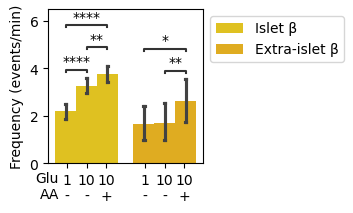

In [ ]:
# single ROI 
from statannotations.Annotator import Annotator
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(2, 2))

sns.barplot(
    data=extra_islet_beta_df, 
    x='cell_type', 
    y='epm', 
    hue='lag', 
    ax=ax,
    palette='gray',
    capsize=0.05
    )
    
celltype_colors = {
    'beta': '#DFC121',
    'extra_beta_cells': '#DFAC21'
}

# get x tick positions and labels
xticks = ax.get_xticks()
xlabels = [t.get_text() for t in ax.get_xticklabels()]

# map tick position -> cell_type
tick_map = dict(zip(xticks, xlabels))

for patch in ax.patches:
    # skip weird zero-size patches if present
    if patch.get_width() <= 0:
        continue

    # center x-position of this bar
    x_center = patch.get_x() + patch.get_width() / 2

    # assign to nearest x tick
    nearest_tick = min(xticks, key=lambda t: abs(t - x_center))
    cell_type = tick_map[nearest_tick]

    patch.set_facecolor(celltype_colors[cell_type])

pairs = [
    (('beta', 'glucose 1mM'), ('beta', 'glucose 10mM')),
    (('beta', 'glucose 1mM'), ('beta', 'glucose 10mM, aa 6mM')),
    (('beta', 'glucose 10mM'), ('beta', 'glucose 10mM, aa 6mM')),

    (('extra_beta_cells', 'glucose 1mM'), ('extra_beta_cells', 'glucose 10mM')),
    (('extra_beta_cells', 'glucose 1mM'), ('extra_beta_cells', 'glucose 10mM, aa 6mM')),
    (('extra_beta_cells', 'glucose 10mM'), ('extra_beta_cells', 'glucose 10mM, aa 6mM')),
]
# label significance stars of Man-Whitney U in the plot
annotator = Annotator(
    ax, pairs,
    data=extra_islet_beta_df, 
    x='cell_type', 
    y='epm', 
    hue='lag', 
)
annotator.configure(
    test='Mann-Whitney',
    text_format='star',
    hide_non_significant=True,
    comparisons_correction='fdr_bh',
    # loc='outside'
)
annotator.apply_and_annotate()

ax.legend().remove()

ax.set_xlabel(None)
ax.set_xticks([-0.25, 0, 0.25, 0.75, 1, 1.25])
ax.set_xticklabels(
    [
    '1\n-', '10\n-', '10\n+', 
    '1\n-', '10\n-', '10\n+'
    ])
ax.set_ylabel('Frequency (events/min)')

ax.text(-0.35, -1.48, 'Glu\nAA', ha='right')

# add legend
legend_elements = [
    Patch(facecolor=color, edgecolor='none', label=label)
    for label, color in 
    zip(['Islet β', 'Extra-islet β'], celltype_colors.values())
]
ax.legend(handles=legend_elements, title=None, bbox_to_anchor=(1, 1))

fig.savefig(
    os.path.join(fig_folder, 'extra_islet_beta_fequency_per_ROI.png'), 
    dpi=300, bbox_inches='tight'
    )
fig.savefig(
    os.path.join(fig_folder, 'extra_islet_beta_fequency_per_ROI.pdf'), 
    dpi=300, bbox_inches='tight'
    )

plt.show()

# Spatial analysis on MT genes

In [ ]:
# remove acinar and ductal genes from the analysis

gs_to_remove = [
    # acinar
    'CEL', 'CELA2A', 'CELA2B', 'CELA3A', 'CELA3B',
    'CPA1', 'CPA2', 'CPB1',
    'CTRB1', 'CTRB2', 'CTRC',
    'AMY2A', 'AMY2B',
    'PRSS1', 'PRSS2', 'PRSS3',
    'PNLIP', 'PNLIPRP1', 'PNLIPRP2','PLIN5'
    'REG1B',
    'GP2',
    'RBPJL',
    'SYCN', 'AQP8', 
    
    # ductal
    'MUC6',
    'ANPEP',
    'SLC16A1',
]

# remove beta spots with no insulin expression
spatial_beta_raw = adata_raw[adata_raw.obs['islet_label'] == 'β'].copy()
spatial_beta_raw_strict = spatial_beta_raw[
    ~ (
        (spatial_beta_raw.obs['Endocrine_type'] == 'extra_endocrine') & 
        (
            (spatial_beta_raw[:, 'INS'].X.toarray()[:, 0] == 0) 
        )
    )
].copy()
spatial_beta_raw_strict_filter = spatial_beta_raw_strict[:, ~ spatial_beta_raw_strict.var_names.isin(gs_to_remove)].copy()

# normalize and logarithme
spatial_beta_strict_filter = spatial_beta_raw_strict_filter.copy()
sc.pp.normalize_total(spatial_beta_strict_filter, target_sum=1e4, inplace=True)  # CP10K scale
sc.pp.log1p(spatial_beta_strict_filter, base=2) # log2 transform  

## all ND-Lean spatial samples

In [ ]:
# filter samples with enough islet and extra islet beta cells
sp_beta_type = pd.crosstab(spatial_beta_raw_strict.obs['sample'], 
                            spatial_beta_raw_strict.obs['Endocrine_type'])
pw_sp_samples = sp_beta_type[
    (sp_beta_type['extra_endocrine'] >= 10) & 
    (sp_beta_type['islet_endocrine'] >= 10)
].index.tolist()

print(f'{len(pw_sp_samples)} samples left')

# get the pairwise log2foldchanges
pw_beta_log2fcs = pd.DataFrame(index=spatial_beta_strict_filter.var_names)

for sample in pw_sp_samples:
    sample_beta = spatial_beta_strict_filter[spatial_beta_strict_filter.obs['sample'] == sample].copy()
    
    sc.tl.rank_genes_groups(
        sample_beta,
        groupby='Endocrine_type',
        method='wilcoxon',
        n_genes=sample_beta.shape[1],  
        use_raw=False,  
        reference='islet_endocrine',
    )
    
    sample_degs = sc.get.rank_genes_groups_df(sample_beta, group='extra_endocrine')
    sample_degs = sample_degs.set_index('names')

    pw_beta_log2fcs[sample] = sample_degs.loc[pw_beta_log2fcs.index]['logfoldchanges']

# filter ND-Lean samples
pw_sp_lean_samples = metadata.loc[pw_sp_samples][
    metadata.loc[pw_sp_samples]['group'] == 'ND-Lean'
    ].index.tolist()

filter_samples = pw_sp_lean_samples.copy()

df_long = pw_beta_log2fcs[filter_samples].loc[
    ['MT-ATP6', 'MT-CO1', 'MT-CO3', 'MT-CYB', 'MT-ND1', 'MT-ND2', 'MT-ND4',]
].T.melt()

# Compute median per gene (category is in 'variable')
medians = df_long.groupby('variable')['value'].median()

# Use a symmetric range around 0 so center=0 makes sense
# vmax = max(abs(medians.min()), abs(medians.max()))
vmax=3.5

cmap = plt.cm.get_cmap("vlag")
norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Palette: map each gene's median to a color using vlag + TwoSlopeNorm
palette = {gene: cmap(norm(med)) for gene, med in medians.items()}

fig, ax = plt.subplots(figsize=(2.5, 2.5))

sns.boxplot(
    data=df_long,
    x='value', 
    y='variable',
    ax=ax,
    palette=palette,
)

sns.stripplot(
    data=df_long,
    x='value', 
    y='variable',
    ax=ax,
    color='k', 
    edgecolor='w', 
    linewidth=0.5,
    size=2.5,
)

ax.set_ylabel(None)
ax.set_xlabel(f'Log$_2$FC (extra-islet vs islet β)')

# Remove grid
ax.grid(False)

# Add colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, pad=0.1, shrink=0.8)
cbar.set_label(f"Median log$_2$FC\n(extra-islet vs islet β)", 
               rotation=90)

ax.set_xticks([-5, -2.5, 0])
ax.set_xlim(-5.8, 0.1)

plt.tight_layout()

plt.savefig(
    os.path.join(fig_folder, 'pairwise_log2fc_mt_genes_extra_islet_beta_cells.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.savefig(
    os.path.join(fig_folder, 'pairwise_log2fc_mt_genes_extra_islet_beta_cells.pdf'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Slice-seq samples

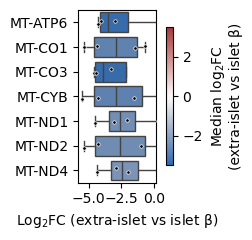

In [ ]:
# get the pairwise log2foldchanges
pw_sp_samples = ['V36', 'V35', 'V34', 'U6-slice']

pw_beta_log2fcs = pd.DataFrame(index=spatial_beta_strict_filter.var_names)

for sample in pw_sp_samples:
    sample_beta = spatial_beta_strict_filter[spatial_beta_strict_filter.obs['sample'] == sample].copy()
    
    sc.tl.rank_genes_groups(
        sample_beta,
        groupby='Endocrine_type',
        method='wilcoxon',
        n_genes=sample_beta.shape[1],  
        use_raw=False,  
        reference='islet_endocrine',
    )
    
    sample_degs = sc.get.rank_genes_groups_df(sample_beta, group='extra_endocrine')
    sample_degs = sample_degs.set_index('names')

    pw_beta_log2fcs[sample] = sample_degs.loc[pw_beta_log2fcs.index]['logfoldchanges']

# filter ND-Lean samples
pw_sp_lean_samples = metadata.loc[pw_sp_samples][
    metadata.loc[pw_sp_samples]['group'] == 'ND-Lean'
    ].index.tolist()

filter_samples = pw_sp_lean_samples.copy()

df_long = pw_beta_log2fcs[filter_samples].loc[
    ['MT-ATP6', 'MT-CO1', 'MT-CO3', 'MT-CYB', 'MT-ND1', 'MT-ND2', 'MT-ND4',]
].T.melt()

# Compute median per gene (category is in 'variable')
medians = df_long.groupby('variable')['value'].median()

# Use a symmetric range around 0 so center=0 makes sense
# vmax = max(abs(medians.min()), abs(medians.max()))
vmax=3.5

cmap = plt.cm.get_cmap("vlag")
norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Palette: map each gene's median to a color using vlag + TwoSlopeNorm
palette = {gene: cmap(norm(med)) for gene, med in medians.items()}

fig, ax = plt.subplots(figsize=(2.5, 2.5))

sns.boxplot(
    data=df_long,
    x='value', 
    y='variable',
    ax=ax,
    palette=palette,
)

sns.stripplot(
    data=df_long,
    x='value', 
    y='variable',
    ax=ax,
    color='k', 
    edgecolor='w', 
    linewidth=0.5,
    size=2.5,
)

ax.set_ylabel(None)
ax.set_xlabel(f'Log$_2$FC (extra-islet vs islet β)')

# Remove grid
ax.grid(False)

# Add colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, pad=0.1, shrink=0.8)
cbar.set_label(f"Median log$_2$FC\n(extra-islet vs islet β)", 
               rotation=90)

ax.set_xticks([-5, -2.5, 0])
ax.set_xlim(-5.8, 0.1)

plt.tight_layout()

plt.savefig(
    os.path.join(fig_folder, 'pairwise_log2fc_mt_genes_extra_islet_beta_cells_slice-seq.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.savefig(
    os.path.join(fig_folder, 'pairwise_log2fc_mt_genes_extra_islet_beta_cells_slice-seq.pdf'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()